# 27 — F pilot leg B: head retrained on calibrated frames + LOIO gate

**Question:** leg A failed because the mosaic-trained head is out-of-distribution on
calibrated-frame embeddings (notebook 26). If we **re-embed the training windows from the
calibrated source frames themselves** and retrain, does the frozen recipe keep its skill?

**Pipeline (SHERLOCK_RUN.md Part F, DECISIONS 2026-07-04b):**

1. `f_leg_b_frame_list.py` — SeamMap footprints ∩ cohort CTX windows → **81 unique CTX frames**
   covering the 38 training images (94 obs×frame pairs).
2. Sherlock 32-task Slurm array (`run_f_leg_b.sbatch` → `f_leg_b_process.sh`): EDR →
   `mroctx2isis` → `spiceinit` → `ctxcal` → `ctxevenodd` → `cam2map` (5 m/px, mosaic CRS).
3. `f_leg_b_extract.py` — windowed I/F crops per (obs, frame) on the exact mosaic grid →
   **73 crops covering 36/38 obs_ids** (2 missing share one failed K04 frame).
4. `f_leg_b_embed.py` (laptop GPU) — composite crops per obs → **perframe normalization**
   (median→125 / IQR→27.7, the leg-A-best mapping) → frozen Fang ViT (S=32/P=96/GeM) →
   `dataset_v2/fang_embeddings_f/` (100% valid tiles).
5. `f_leg_b_loio.py` — pre-registered LOIO gate on the **common 36 images** (both stores
   restricted identically, train AND test): **Δ median per-image AUC ≥ −0.02** (same bar as
   the A1 cycle, which measured −0.024).


In [1]:
import sys
from pathlib import Path

REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").exists())
sys.path.insert(0, str(REPO))
import src.modeling  # noqa: F401  OpenMP bootstrap; must precede numpy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.metrics import roc_auc_score

FIG = REPO / "reports" / "figures"
LEGB = REPO / "reports" / "f_leg_b"

preds = pd.read_csv(FIG / "f_leg_b_loio_preds.csv")
summary = pd.read_csv(FIG / "f_leg_b_loio_summary.csv")
diag = pd.read_csv(LEGB / "diag_per_image.csv")
contrast = pd.read_csv(LEGB / "diag_uint8_contrast.csv")
print(f"preds rows: {len(preds)}  images: {preds.obs_id.nunique()}")


preds rows: 307326  images: 36


## §1 — The gate: FAIL at Δ = −0.0499

Baseline = `fang_embeddings` (mosaic windows, the frozen-recipe store). F =
`fang_embeddings_f` (calibrated-frame composites, perframe-normalized). Same folds, same
head (`DeployableHead` mlp_ens3), same target (`fa_gt_1e-2`).


In [2]:
print(summary.to_string(index=False))
b, f = summary.iloc[0], summary.iloc[1]
d_med = f["median_auc"] - b["median_auc"]
print(f"\nΔ median per-image AUC (F − baseline) = {d_med:+.4f}   (gate ≥ −0.02; A1 was −0.024)")
print(f"Δ pooled PR-AUC                        = {f['pooled_pr_auc'] - b['pooled_pr_auc']:+.4f}")
print(f"\nGATE: {'PASS' if d_med >= -0.02 else 'FAIL'}")


            store  n_img  median_auc  mean_auc  frac_ge_0p7  pooled_pr_auc
  fang_embeddings     36    0.786003  0.771404     0.805556       0.766827
fang_embeddings_f     36    0.736060  0.695478     0.583333       0.625761

Δ median per-image AUC (F − baseline) = -0.0499   (gate ≥ −0.02; A1 was −0.024)
Δ pooled PR-AUC                        = -0.1411

GATE: FAIL


## §2 — But the failure is bimodal, not uniform

Per-image AUC from the banked LOIO predictions. If F were uniformly degrading the signal we
would see every bar shift down ~0.05. Instead **11 images improve** (up to +0.155 — including
the project-best per-image AUC 0.951 on ESP_055978_2270) while **8 drop below 0.5**
(anti-prediction). Something image-specific is breaking, not the recipe as a whole.


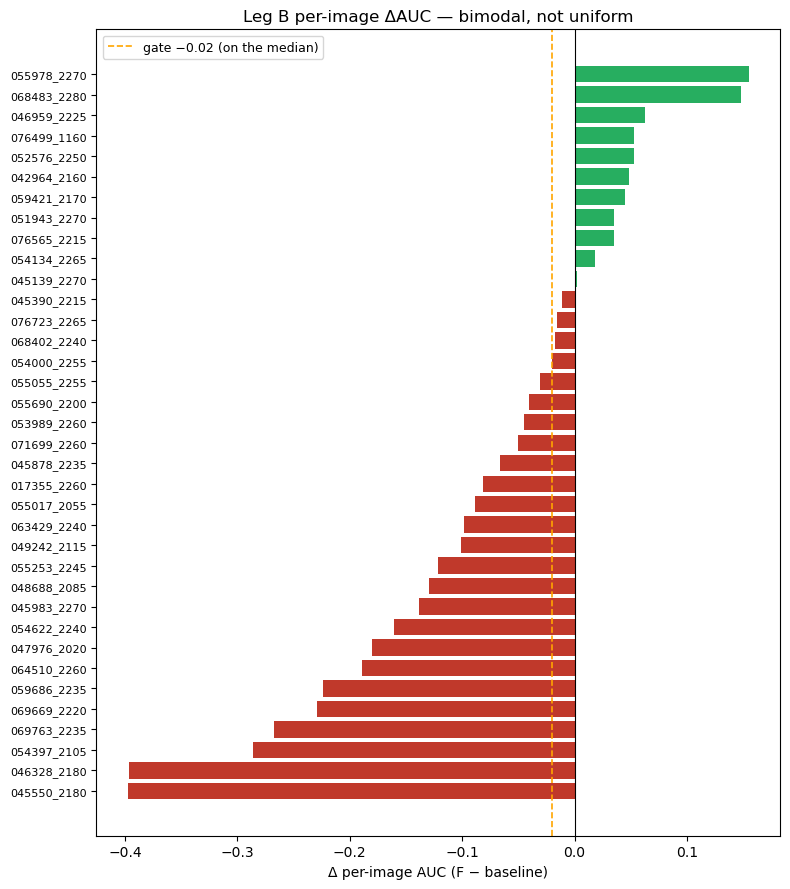

improve: 11/36   F below 0.5: 8/36

worst 5:
                 auc_base  auc_f  d_auc
obs_id                                 
ESP_045550_2180     0.784  0.386 -0.398
ESP_046328_2180     0.752  0.355 -0.397
ESP_054397_2105     0.711  0.424 -0.286
ESP_069763_2235     0.713  0.446 -0.267
ESP_069669_2220     0.690  0.461 -0.229

best 5:
                 auc_base  auc_f  d_auc
obs_id                                 
ESP_052576_2250     0.825  0.878  0.053
ESP_076499_1160     0.849  0.902  0.053
ESP_046959_2225     0.843  0.905  0.062
ESP_068483_2280     0.611  0.759  0.148
ESP_055978_2270     0.796  0.951  0.155


In [3]:
rows = []
for (obs, store), g in preds.groupby(["obs_id", "store"]):
    if g["y"].nunique() == 2:
        rows.append(dict(obs_id=obs, store=store, auc=roc_auc_score(g["y"], g["p"])))
auc = pd.DataFrame(rows).pivot(index="obs_id", columns="store", values="auc")
auc.columns = [c.replace("fang_embeddings_f", "auc_f").replace("fang_embeddings", "auc_base")
               for c in auc.columns]
auc["d_auc"] = auc["auc_f"] - auc["auc_base"]
auc = auc.sort_values("d_auc")

fig, ax = plt.subplots(figsize=(8, 9))
colors = ["#c0392b" if v < 0 else "#27ae60" for v in auc["d_auc"]]
ax.barh(range(len(auc)), auc["d_auc"], color=colors)
ax.set_yticks(range(len(auc)))
ax.set_yticklabels([o.replace("ESP_", "") for o in auc.index], fontsize=8)
ax.axvline(0, color="k", lw=0.8)
ax.axvline(-0.02, color="orange", ls="--", lw=1.2, label="gate −0.02 (on the median)")
ax.set_xlabel("Δ per-image AUC (F − baseline)")
ax.set_title("Leg B per-image ΔAUC — bimodal, not uniform")
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(FIG / "27_f_legb_dauc_bars.png", dpi=110); plt.show()

n_up, n_below = int((auc.d_auc > 0).sum()), int((auc.auc_f < 0.5).sum())
print(f"improve: {n_up}/36   F below 0.5: {n_below}/36")
print("\nworst 5:");  print(auc.head(5).to_string(float_format=lambda x: f"{x:.3f}"))
print("\nbest 5:");   print(auc.tail(5).to_string(float_format=lambda x: f"{x:.3f}"))


## §3 — Diagnostics: what separates the craters from the improvers?

Three rounds (`scripts/probes/_f_leg_b_diag.py`, `_f_leg_b_crop_stats.py`,
`_f_leg_b_uint8_contrast.py`):

1. **Composite mechanics: ruled out.** Coverage ≈ 100% on every image; number of crops and
   frame-overlap fraction are null vs ΔAUC (|ρ| < 0.07).
2. **Between-frame illumination mismatch inside a composite: ruled out** (anti-correlates).
   The improvers carry the big frame-median ratios (1.43–1.58×); the craters' frames agree
   (1.02–1.30×). The last-write-wins composite + single normalization is not the killer.
3. **Over-stretch hypothesis: REFUTED on real quantities.** The perframe mapping pins *every*
   F window at uint8 IQR 27–28 by construction (mosaic windows vary 19–57); the F/mosaic
   contrast ratio is null vs ΔAUC (ρ = +0.09).

**Survivor: the composite I/F median (ρ = +0.35) — dim scenes crater, bright scenes improve.**
That is an illumination axis: leg A0 measured per-frame I/F median ↔ cos(incidence) r = +0.83.
The perframe level-shift removes the *level* difference but evidently not whatever changes in
dim-scene *texture* relative to the mosaic's rendering of the same ground.


Spearman correlations with d_auc:
  coverage    rho = +0.163
  overlap     rho = -0.059
  n_crops     rho = -0.063
  if_iqr      rho = +0.242
  if_median   rho = +0.347
  iqr_ratio   rho = +0.091


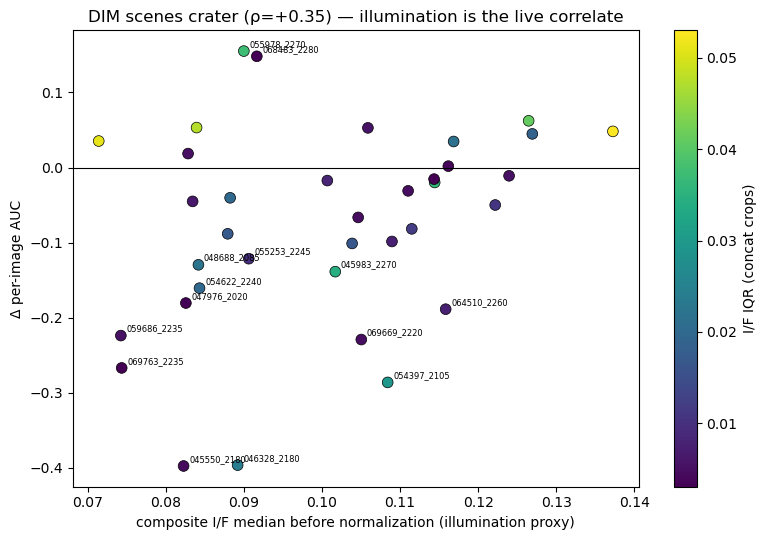

In [4]:
df = diag.merge(contrast[["obs_id", "mosaic_iqr", "f_iqr", "iqr_ratio"]], on="obs_id")

print("Spearman correlations with d_auc:")
for c in ("coverage", "overlap", "n_crops", "if_iqr", "if_median", "iqr_ratio"):
    print(f"  {c:10s}  rho = {df['d_auc'].corr(df[c], method='spearman'):+.3f}")

fig, ax = plt.subplots(figsize=(8, 5.5))
sc = ax.scatter(df["if_median"], df["d_auc"], c=df["if_iqr"], cmap="viridis",
                s=60, edgecolor="k", lw=0.5)
ax.axhline(0, color="k", lw=0.8)
for _, r in df.iterrows():
    if abs(r["d_auc"]) > 0.12:
        ax.annotate(r["obs_id"].replace("ESP_", ""), (r["if_median"], r["d_auc"]),
                    fontsize=6, xytext=(4, 3), textcoords="offset points")
ax.set_xlabel("composite I/F median before normalization (illumination proxy)")
ax.set_ylabel("Δ per-image AUC")
ax.set_title("DIM scenes crater (ρ=+0.35) — illumination is the live correlate")
plt.colorbar(sc, ax=ax, label="I/F IQR (concat crops)")
fig.tight_layout()
fig.savefig(FIG / "27_f_legb_median_scatter.png", dpi=110); plt.show()


## §4 — What the embedder saw: mosaic vs F composite

3 worst craters (top) and 3 best improvers (bottom); each row = baseline mosaic window |
F perframe composite (identical 0–255 gray scale) | 512-px native-res zoom of each.
Rendered by `scripts/probes/_f_leg_b_figures.py` from the actual embed code path
(`f_leg_b_embed.composite_crops`).

Note the crater F zooms are visibly texture-poor next to their mosaic counterparts, while the
improver F windows look as good as the mosaic — even where they contain obvious brightness
seams between frames (seams don't hurt; per-crop stats confirm).


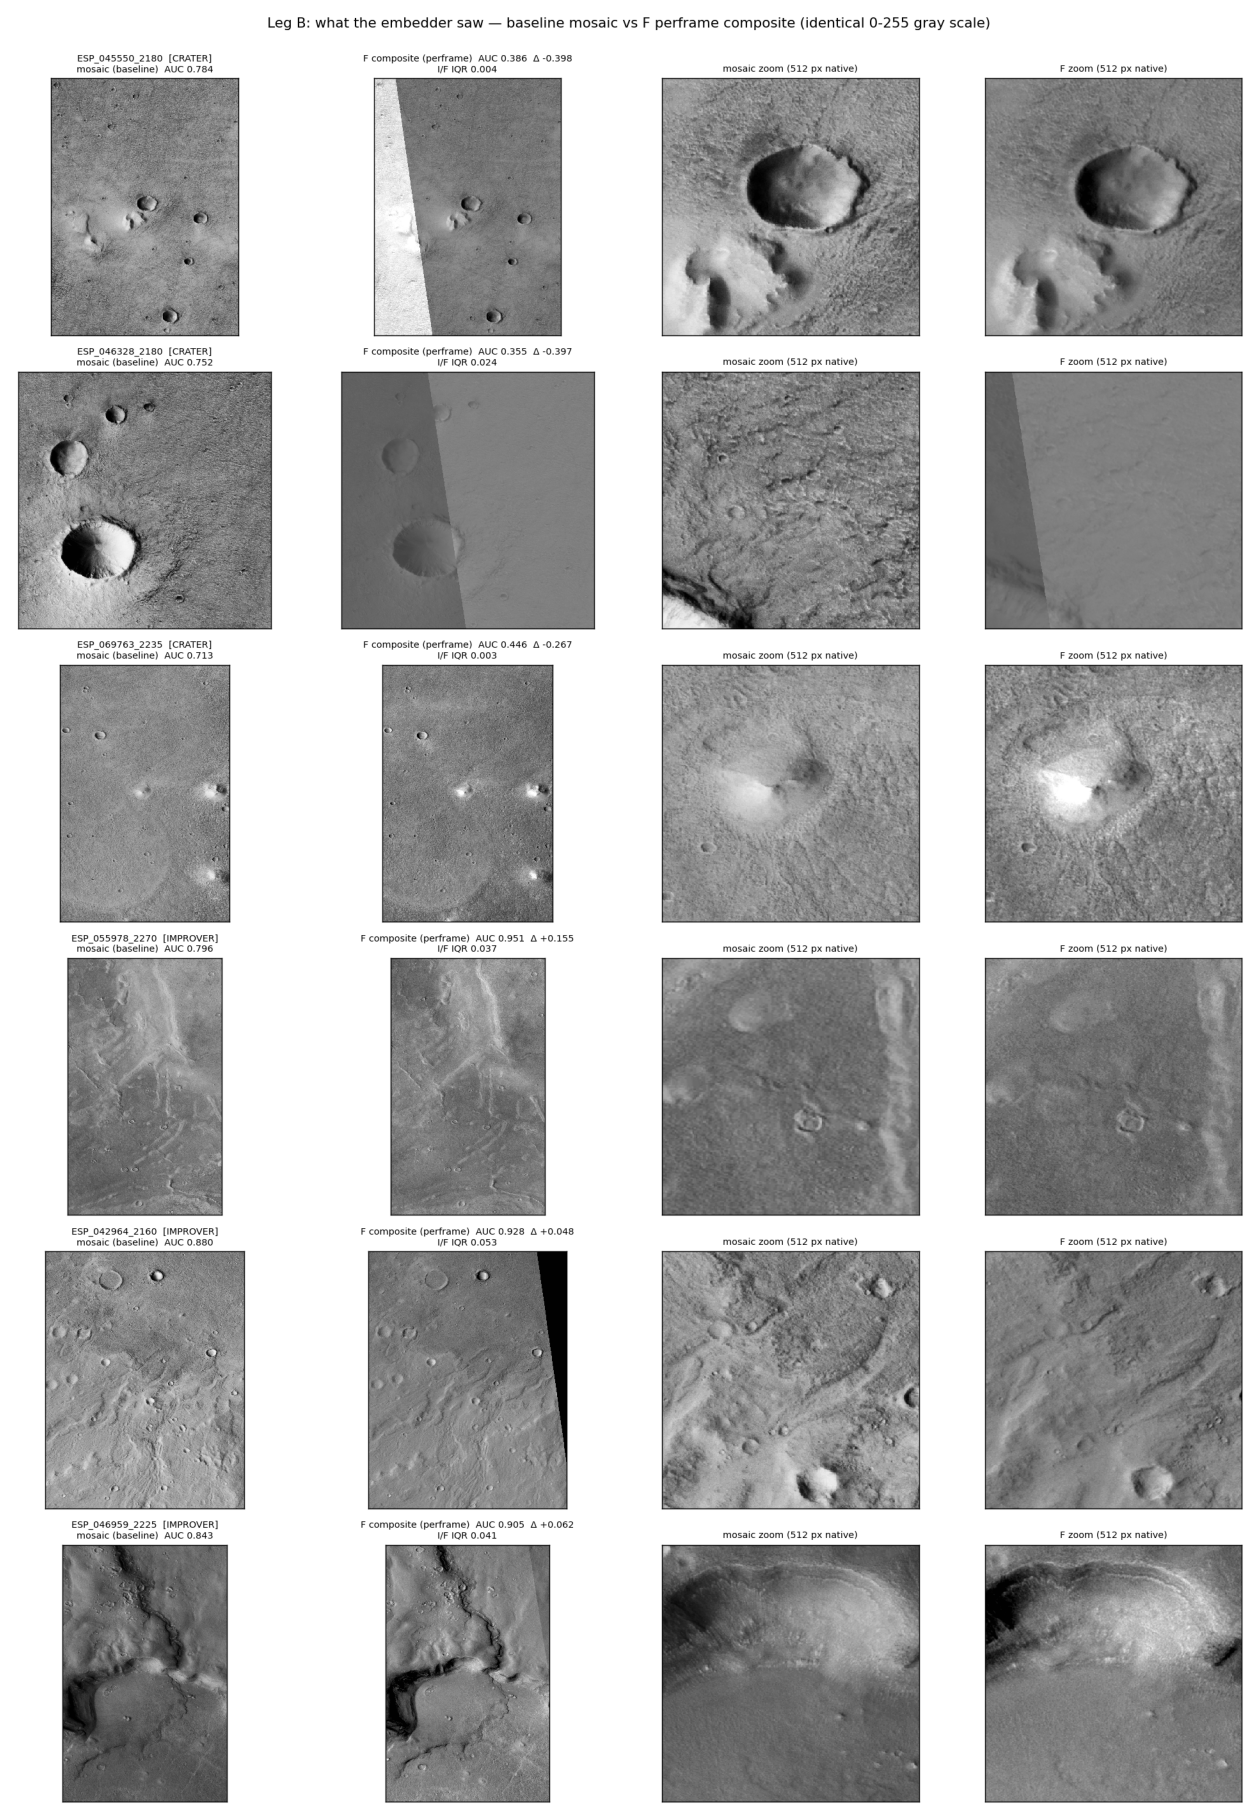

In [5]:
fig, ax = plt.subplots(figsize=(16, 24))
ax.imshow(mpimg.imread(FIG / "f_leg_b_diag_gallery.png")); ax.axis("off")
plt.show()


In [6]:
# per-crop I/F stats for the 6 gallery images (from _f_leg_b_crop_stats.py)
stats = pd.DataFrame([
    ("ESP_045550_2180", "CRATER",   -0.398, "F04_037242 / G19_025559", 1.25),
    ("ESP_046328_2180", "CRATER",   -0.397, "D04_028658 / G20_026192", 1.30),
    ("ESP_069763_2235", "CRATER",   -0.267, "K04_055123 / P02_002009", 1.02),
    ("ESP_055978_2270", "IMPROVER", +0.155, "B18_016498 / F04_037530", 1.43),
    ("ESP_042964_2160", "IMPROVER", +0.048, "B04_011277 / P20_008864", 1.58),
    ("ESP_046959_2225", "IMPROVER", +0.062, "J04_046537 / P16 / P17",  1.51),
], columns=["obs_id", "kind", "d_auc", "frames", "frame_median_ratio"])
print(stats.to_string(index=False))
print("\nThe improvers carry the BIG between-frame illumination mismatches —")
print("composite seams are not the failure mode.")


         obs_id     kind  d_auc                  frames  frame_median_ratio
ESP_045550_2180   CRATER -0.398 F04_037242 / G19_025559                1.25
ESP_046328_2180   CRATER -0.397 D04_028658 / G20_026192                1.30
ESP_069763_2235   CRATER -0.267 K04_055123 / P02_002009                1.02
ESP_055978_2270 IMPROVER  0.155 B18_016498 / F04_037530                1.43
ESP_042964_2160 IMPROVER  0.048 B04_011277 / P20_008864                1.58
ESP_046959_2225 IMPROVER  0.062  J04_046537 / P16 / P17                1.51

The improvers carry the BIG between-frame illumination mismatches —
composite seams are not the failure mode.


## §5 — Verdict and where this leaves F

**Gate: FAIL** — Δ median per-image AUC = **−0.0499** vs the −0.02 bar (median 0.786 → 0.736,
pooled PR-AUC 0.767 → 0.626 on the common 36 images).

**But leg B does NOT kill F:**

- The improvers include some of the best per-image AUCs in the whole project (0.951, 0.934,
  0.928) — calibrated frames carry at least as much signal as the mosaic where they work.
- The failure is concentrated in **dim (high-incidence) scenes**, the exact axis leg A0
  flagged (I/F median ↔ cos i, r = +0.83) and the failure mode the **minnaert mapping**
  (÷cos^k(i), k ≈ 0.66–0.69, metadata-only at deploy) was designed for.
- Iterating is cheap: the crops are on the laptop, so a new I/F→uint8 mapping is **~1 h of
  laptop GPU** (re-embed + re-gate), no Sherlock.

**Options on the table (decision → Brian):**

| option | cost | rationale |
|---|---|---|
| iterate: **minnaert** mapping | ~1 h GPU | targets the surviving illumination correlate directly |
| iterate: global affine (control) | ~1 h GPU | "calibrated frames need no per-frame norm" bet |
| close F → E / cheap A-fixes | — | accept 2 pilots' FAILs as final |

Full record: DECISIONS 2026-07-04b; PLAN_StripingArtifact leg-B bullet.
